In [1]:
import gymnasium as gym
from gymnasium_env import BlokusEnv
from src.agents.agent import Agent, RandomAgent, SimpleFunctionAgent, MiniMaxAgent
# GreedyAgent, MCTSAgent, MCTSAgent2
import numpy as np
from tqdm import tqdm
import pickle
import cProfile

/Users/mario/Documents/proj/cam/Blokus/venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:642: UserWarning: WARN: Overriding environment gymnasium_env/Blokus-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [2]:
class SingleAgentBlokusEnv(BlokusEnv):
    AGENT_INDEX = 2
    def __init__(self, hidden_agent_policy = "random",  *args, **kwargs, ):
        super(SingleAgentBlokusEnv, self).__init__(*args, **kwargs)
        # self.agent = RandomAgent(name="random_hidden_agent")
        self.agent = MiniMaxAgent(name="minimax", depth=2, board_size=7)
        
    def step(self, action):
        assert self.current_player == 1
        # assert False # check this!!! There is a bug here

        obs, total_reward, terminated, truncated, info = super(SingleAgentBlokusEnv, self).step(action)
        if terminated or truncated: 
            return obs, total_reward, terminated, truncated, info
        
        while self.current_player == self.AGENT_INDEX:
            # actions = self.possible_actions(self.AGENT_INDEX) # get possible actions for the random agent
            assert len(obs["possible_actions"]) > 0
            action = self.agent.get_action(self, obs)
            # print(f"Agent action: {self._action_to_tuple(action)}")
            obs, reward, terminated, truncated, info = super(SingleAgentBlokusEnv, self).step(action)
            total_reward -= reward
            assert not truncated
            if terminated:
                return obs, total_reward, terminated, truncated, info
        
        return obs, total_reward, terminated, truncated, info

    def reset(self, *args, **kwargs):
        return super(SingleAgentBlokusEnv, self).reset(*args, **kwargs)

# Create an instance of the custom environment

In [3]:
env = SingleAgentBlokusEnv(board_size=7, num_players=2, render_mode="console", render_scale=10, mode = "good")

Neighborhood to encoded actions loaded
Initialised on good mode
Initialised on good mode
Cache loaded for MiniMaxAgent with depth 2 and board size 7


In [4]:
import numpy as np
from tqdm import tqdm
import pickle
import cProfile
import subprocess
import os

q_table = {}

AGENT_NAME = 'q_table6.pkl'
try:
    with open(AGENT_NAME, 'rb') as f:
        q_table = pickle.load(f)
except FileNotFoundError:
    q_table = {}
    
def encode_board(board: np.ndarray) -> str:
    return ''.join(map(str, board.flatten()))

def decode_board(encoded_board : str, n: int) -> np.ndarray:
    board = []
    board = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(n):
            board[i, j] = int(encoded_board[i * n + j])
    return board

def create_q_table(state: str, actions: np.ndarray):
    if state not in q_table:
        q_table[state] = {action: 0 for action in actions}

def get_q_value(state: str, action: int) -> float:
    return q_table[state][action]

def set_q_value(state: str, action: int, value: float):
    q_table[state][action] = value

def argmax(state: str) -> int:
    return max(q_table[state], key=q_table[state].get)

def maxi(state: str) -> float:
    if len(q_table[state].values()) == 0:
        return 0
    return max(q_table[state].values())

a = 0
win_accuracy = 70
random_agent = RandomAgent(name="random_agent")
agent = random_agent
def main(num_episodes = 250000):
    global a
    # Initialize Q-table
    env.render_mode = "console"

    # Hyperparameters
    alpha = 0.01  # Learning rate
    # min_alpha = 0.01
    gamma = 0.995  # Discount factor
    epsilon = 1.0  # Exploration rate
    # epsilon = 0.01  # Exploration rate
    epsilon_decay = 0.9995
    min_epsilon = 0.01
    beta = (1 / (alpha * 10)) ** (1 / 5)
    print(f"beta: {beta}")
    # alpha = 0.1  # Learning rate
    # gamma = 0.995  # Discount factor
    # epsilon = 1.0  # Exploration rate
    # epsilon_decay = 0.9999
    # min_epsilon = 0.01
    # num_episodes = 250000

    win_counter, tie_counter, lose_counter = 0, 0, 0

    # Q-learning algorithm
    pbar = tqdm(range(num_episodes))
    win_rate = []
    tie_rate = []
    loss_rate = []
    last_win_counter = 0
    try:
        states_before = len(env.agent.cache)
    except:
        states_before = 0
    for i in pbar:
        # pbar.set_description(f"Episode {i+1}: Wins: {win_counter}, Ties: {tie_counter}, Losses: {lose_counter}, Epsilon: {epsilon:.4f}")
        obs, info = env.reset()
        state = encode_board(obs["state"])
        done = False
        create_q_table(state, obs["possible_actions"])
        total_reward = 0
        while not done:
            if np.random.uniform(0, 1) < epsilon:
                action = agent.get_action(env, obs) # Explore action space
                # print(obs["possible_actions"])
            else:
                action = argmax(state)  # Exploit learned values

            # print(action, state, obs["possible_actions"])
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = encode_board(next_obs["state"])
            obs = next_obs
            # Update Q-table
            create_q_table(next_state, next_obs["possible_actions"])
            total_reward += reward
            estimated_reward = reward + gamma * maxi(next_state)
            lr_scale = beta ** np.clip(-estimated_reward, 0, 5)
            # if done:
            #     if total_reward > 0:
            #         reward1 = reward + 5
            #     elif total_reward == 0:
            #         reward1 = reward - 10
            #     else:
            #         reward1 = reward - 100
            # else:
            #     if total_reward + maxi(next_state) > 0:
            #         reward1 = reward + 2
            #     elif total_reward + maxi(next_state) == 0:
            #         reward1 = reward - 2
            #     else:
            #         reward1 = reward - 20
            set_q_value(state, action, get_q_value(state, action) + alpha * lr_scale * (reward + gamma * (1 - done) * maxi(next_state) - get_q_value(state, action)))
            # q_table[state, action] = q_table[state, action] + alpha * (reward + gamma * np.max(q_table[next_state]) - q_table[state, action])
            done = terminated or truncated
            state = next_state
            if terminated:
                if total_reward > 0:
                    win_counter += 1
                elif total_reward == 0:
                    tie_counter += 1
                else:
                    lose_counter += 1
            
            if truncated:
                print("Truncated")
                assert False
        if (i + 1) % 100 == 0:
            last_win_counter = win_counter
            try:
                cache_size = len(env.agent.cache)
            except:
                cache_size = 0
            pbar.set_description(f"E {i+1}: W: {win_counter}, T: {tie_counter}, L: {lose_counter}, ε: {epsilon:.4f}, S: {len(q_table)}, Cache: {cache_size}")
            win_counter = 0
            tie_counter = 0
            lose_counter = 0
        if i < num_episodes - 100 + 1:
            epsilon = max(min_epsilon, epsilon * epsilon_decay)
            # alpha = max(min_alpha, alpha * epsilon_decay)
        else:
            epsilon = 0
    global win_accuracy
    with open(AGENT_NAME, 'wb') as f:
        pickle.dump(q_table, f)
    print(f"Q-table saved with accuracy {last_win_counter}")
    try:
        states_after = len(env.agent.cache)
        env.agent.save_cache()
        print(f"States discovered: {states_after - states_before}")
        print(states_before, states_after)
    except:
        pass

    win_accuracy = last_win_counter
    if last_win_counter > 90:
        print("Win rate above 90%")
    else:
        main(num_episodes)
        a += 1

# cProfile.run("main()", sort=  "cumtime")

In [5]:
import pstats

try:
    # Run the profiler
    cProfile.run("main(20000)", "profile_output")
finally:
    # Create a Stats object
    p = pstats.Stats("profile_output")

    # Set the precision for the output
    p.strip_dirs().sort_stats("cumtime").print_stats()

    # Print the stats with custom formatting
    for func in p.fcn_list:
        stats = p.stats[func]
        ncalls = stats[0]
        tottime = stats[2]
        percall = tottime / ncalls if ncalls else 0
        cumtime = stats[3]
        filename = func[0]
        lineno = func[1]
        funcname = func[2]
        print(f"{ncalls:>8} {tottime:>8.3f} {percall:>8.3f} {cumtime:>8.3f} {percall:>8.8f} {filename}:{lineno}({funcname})")

    print(a)

beta: 1.5848931924611136


E 20000: W: 83, T: 16, L: 1, ε: 0.0000, S: 255608, Cache: 297371: 100%|██████████| 20000/20000 [00:55<00:00, 357.94it/s] 


Q-table saved with accuracy 83
States discovered: 9782
287589 297371
beta: 1.5848931924611136


E 20000: W: 81, T: 14, L: 5, ε: 0.0000, S: 267453, Cache: 306961: 100%|██████████| 20000/20000 [00:56<00:00, 353.56it/s] 


Q-table saved with accuracy 81
States discovered: 9590
297371 306961
beta: 1.5848931924611136


...

Q-table saved with accuracy 85
States discovered: 9074
435970 445044
beta: 1.5848931924611136


E 20000: W: 87, T: 5, L: 8, ε: 0.0000, S: 451764, Cache: 453906: 100%|██████████| 20000/20000 [00:46<00:00, 426.75it/s]  


Q-table saved with accuracy 87
States discovered: 8862
445044 453906
beta: 1.5848931924611136


E 20000: W: 91, T: 7, L: 2, ε: 0.0000, S: 462825, Cache: 462549: 100%|██████████| 20000/20000 [00:46<00:00, 430.48it/s] 


Q-table saved with accuracy 91
States discovered: 8643
453906 462549
Win rate above 90%
Wed Dec 11 13:52:13 2024    profile_output

         1849679674 function calls (1846038008 primitive calls) in 1105.229 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    40650    7.948    0.000 2516.058    0.062 base_events.py:1909(_run_once)
      5/1    0.000    0.000 1105.202 1105.202 {built-in method builtins.exec}
      2/1    0.000    0.000 1045.148 1045.148 <string>:1(<module>)
     20/1    0.001    0.000  985.016  985.016 2101011923.py:50(main)
  1957467    3.118    0.000  941.931    0.000 1359104866.py:8(step)
  6638982   10.514    0.000  796.778    0.000 blokus_env.py:558(step)
 14990536    9.154    0.000  665.271    0.000 blokus_env.py:413(possible_actions)
  8351554   21.282    0.000  630.910    0.000 blokus_env.py:489(possible_actions_precomputed)
 18137817  242.505    0.000  566.003    0.000 blokus_env.py:504(possible_a

In [6]:
states_after = len(env.agent.cache)
# print(f"States discovered: {states_after - states_before}")
env.agent.save_cache()
print(states_after)
with open(AGENT_NAME, 'wb') as f:
    pickle.dump(q_table, f)

462549


In [7]:
# print(env.agent.cache)

In [10]:
import random

q_table = {}
def encode_board(board: np.ndarray) -> str:
    return ''.join(map(str, board.flatten()))

def decode_board(encoded_board : str, n: int) -> np.ndarray:
    board = []
    board = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(n):
            board[i, j] = int(encoded_board[i * n + j])
    return board

def create_q_table(state: str, actions: np.ndarray):
    if state not in q_table:
        q_table[state] = {action: 0 for action in actions}
    
def get_q_value(state: str, action: int) -> float:
    return q_table[state][action]

def set_q_value(state: str, action: int, value: float):
    q_table[state][action] = value

not_visited = 0
def argmax(state: str) -> int:
    if not state in q_table:
        global not_visited
        not_visited += 1
        return -1
    return max(q_table[state], key=q_table[state].get)

def maxi(state: str) -> float:
    if len(q_table[state].values()) == 0:
        return 0
    return max(q_table[state].values())

# env.render_mode = "human"
# env.render_mode = "console"
# AGENT_NAME = 'q_table6.pkl'
with open(AGENT_NAME, 'rb') as f:
    q_table = pickle.load(f)
    
def heuristic(env1, actions):
    def f(x):
        h, w, pid, pt = env1._action_to_tuple(x)
        return len(env1.pieces[pid].transformations[pt].shape)
    # print(np.vectorize(f)(actions))
    values = np.vectorize(f)(actions)
    max_value = np.max(values)
    idx = random.choice(np.where(values == max_value)[0])
    return actions[idx]
random_agent1 = RandomAgent()
greedy_agent1 = SimpleFunctionAgent(name="hey", func=heuristic)
helper_agent = random_agent1
# opponent_agent = gree
random_agent = RandomAgent()
greedy_agent = SimpleFunctionAgent(name="hey", func=heuristic)
minimax_agent = MiniMaxAgent(name="minimax", depth=2, board_size=7)
env.agent = greedy_agent
# env.render_mode = "human"
env.render_mode = "console"
num_states = 0
def test_agent(env, num_episodes=100):
    global q_table
    win_counter, tie_counter, lose_counter = 0, 0, 0
    global num_states
    for _ in range(num_episodes):
        obs, info = env.reset()
        state = encode_board(obs["state"])
        done = False
        total_reward = 0

        while not done:
            num_states += 1
            action = argmax(state)  # Use the trained agent's policy
            if action == -1:
                action = helper_agent.get_action(env, obs)
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = encode_board(next_obs["state"])
            state = next_state
            obs = next_obs
            total_reward += reward
            done = terminated or truncated
            # env.render()
        if total_reward > 0:
            win_counter += 1
        elif total_reward == 0:
            tie_counter += 1
        else:
            lose_counter += 1

    return win_counter, tie_counter, lose_counter

print(get_q_value("0" * 49, 58))
print(argmax("0" * 49))

win_counter1 = np.zeros(1000)
tie_counter1 = np.zeros(1000)
lose_counter1 = np.zeros(1000)
# Test the agent
prange = tqdm(range(1000))
for i in prange:
    win_counter1[i], tie_counter1[i], lose_counter1[i] = test_agent(env)
    prange.set_description(f"W: {win_counter1[:i+1].mean():.3f}, T: {tie_counter1[:i+1].mean():.3f}, L: {lose_counter1[:i+1].mean():.3f}, NV: {not_visited / (num_states) * 100:.3f}%")

print(f"Number of not visited states: {not_visited}")

Initialised on good mode
Cache loaded for MiniMaxAgent with depth 2 and board size 7
0.10227166548994526
57


W: 77.439, T: 10.159, L: 12.402, NV: 8.033%:  16%|█▋        | 164/1000 [00:15<01:16, 10.93it/s]


KeyboardInterrupt: 

Number of win_counter less than 75: 76


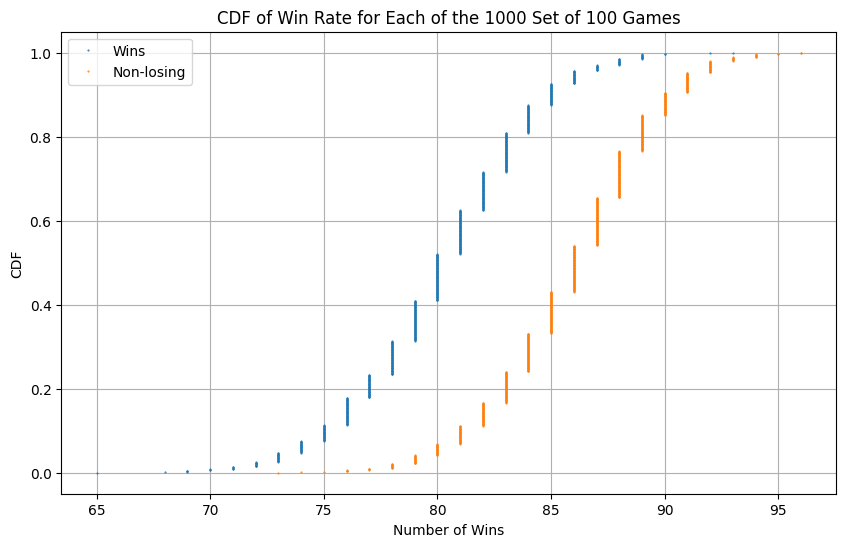

In [ ]:
import matplotlib.pyplot as plt

win_counter = win_counter1
tie_counter = tie_counter1
lose_counter = lose_counter1
non_losing_counter = win_counter + tie_counter
# Calculate the CDF
win_counter_sorted = np.sort(win_counter)
cdf = np.arange(1, len(win_counter_sorted) + 1) / len(win_counter_sorted)

# Plot the CDF for wins
plt.figure(figsize=(10, 6))
plt.plot(win_counter_sorted, cdf, marker='.', linestyle='none', label='Wins', markersize=1)
plt.xlabel('Number of Wins')
plt.ylabel('CDF')
plt.title('CDF of Win Rate for Each of the 1000 Set of 100 Games')
plt.grid(True)

num_wins_less_than_75 = np.sum(win_counter < 75)
print(f"Number of win_counter less than 75: {num_wins_less_than_75}")

# Calculate and plot the CDF for non-losing counter
non_losing_counter_sorted = np.sort(non_losing_counter)
cdf_non_losing = np.arange(1, len(non_losing_counter_sorted) + 1) / len(non_losing_counter_sorted)
plt.plot(non_losing_counter_sorted, cdf_non_losing, marker='.', linestyle='none', label='Non-losing', markersize=1)

plt.legend()
plt.show()

In [ ]:
print(sum(win_counter),sum(non_losing_counter))

80189.0 85927.0
